# **Machine Learning in Customer Subscription of Bank Term Deposits**

Dataset Link: https://archive.ics.uci.edu/dataset/222/bank+marketing

# Importing Dataset From UCI ML Repository

In [ ]:
!pip install ucimlrepo -q
!pip install tensorflow -q

In [6]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

# Data Preprocessing

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# Separate features and target
X = X.copy()
y = y.copy()

# Convert target to binary
y['y'] = y['y'].map({'no': 0, 'yes': 1})

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Final shape after preprocessing
print("Training data shape after preprocessing:", X_train_processed.shape)
print("Test data shape after preprocessing:", X_test_processed.shape)

Training data shape after preprocessing: (36168, 47)
Test data shape after preprocessing: (9043, 47)


# Exploratory Data Analysis (EDA)

Dataset shape:
(45211, 17)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB
None

Statistical su

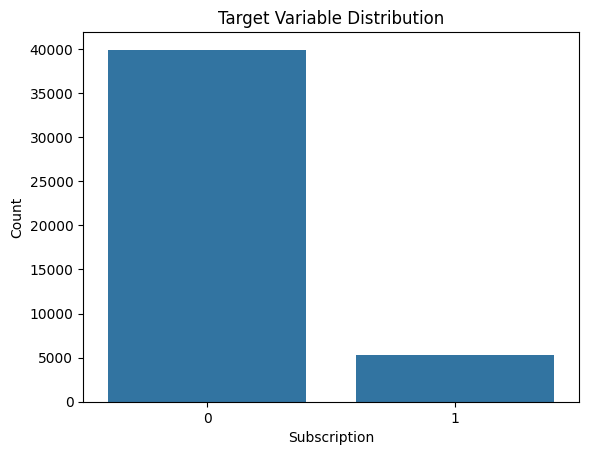

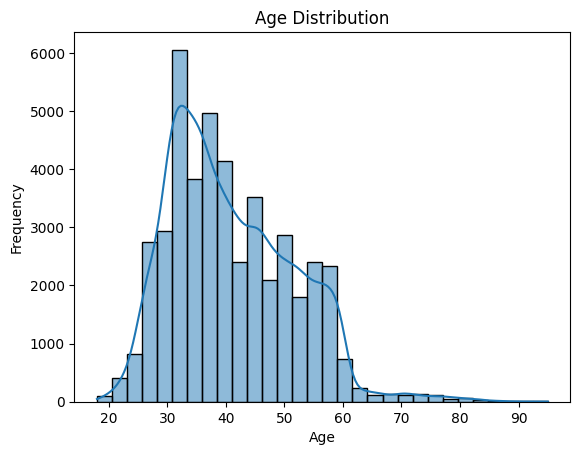

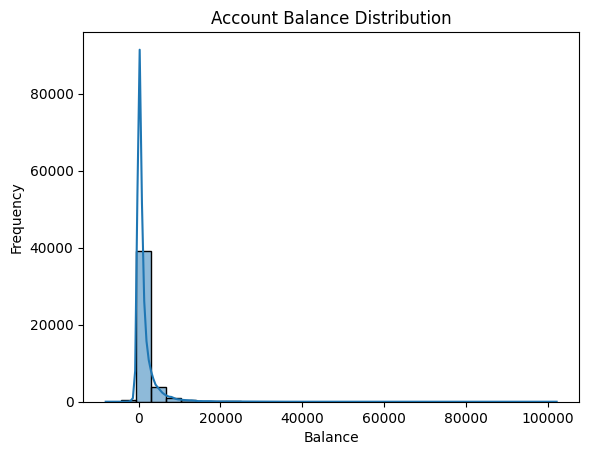

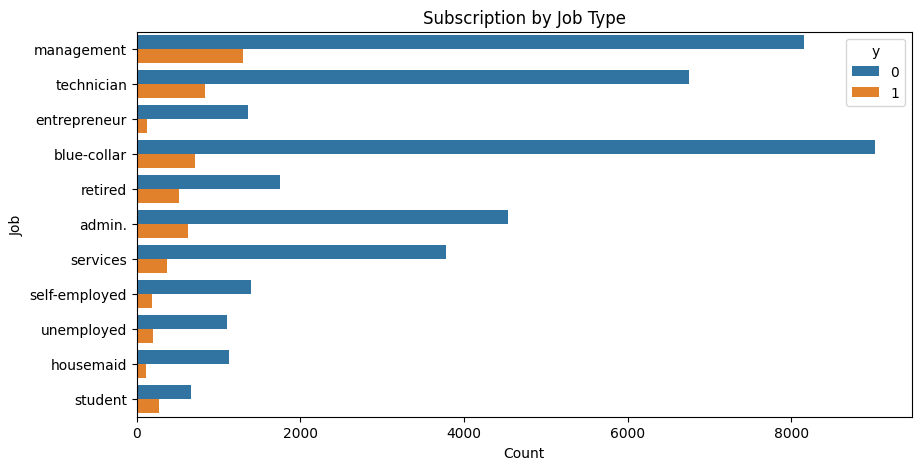

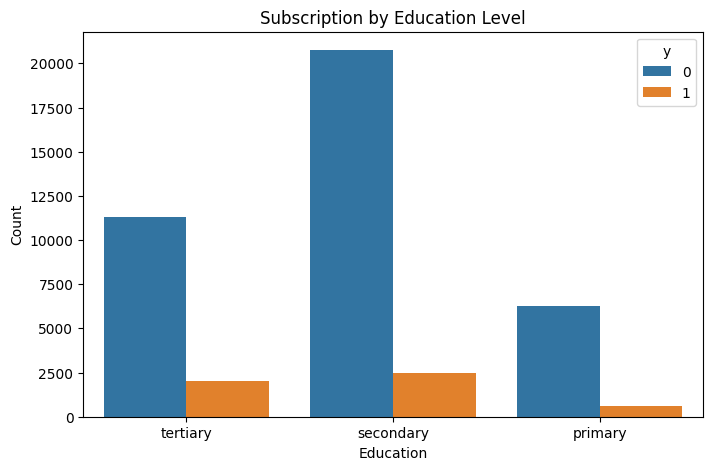

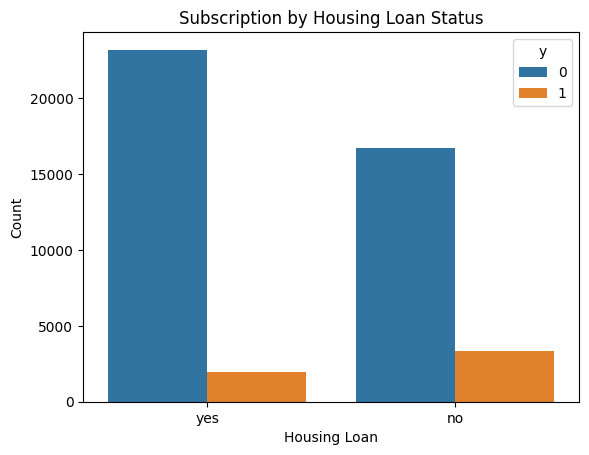

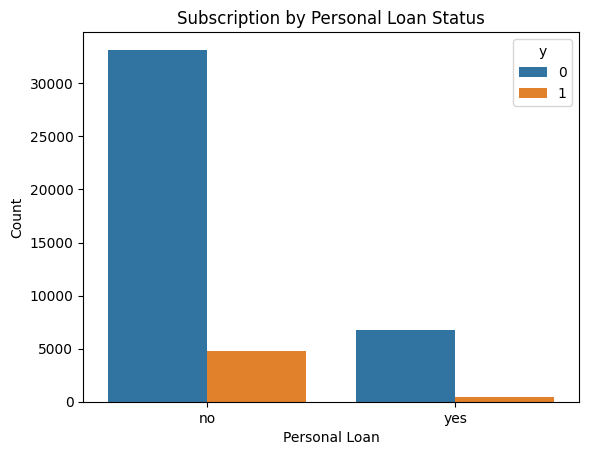

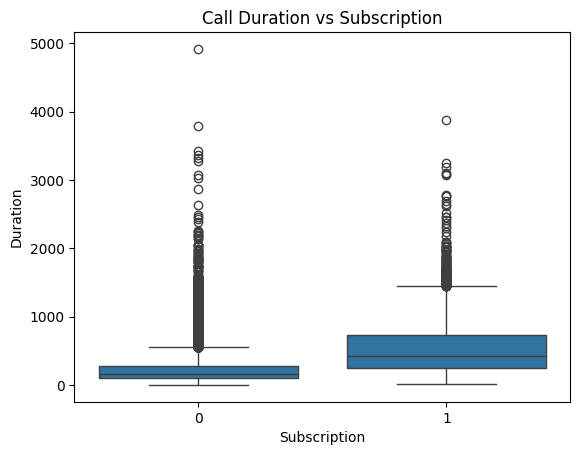

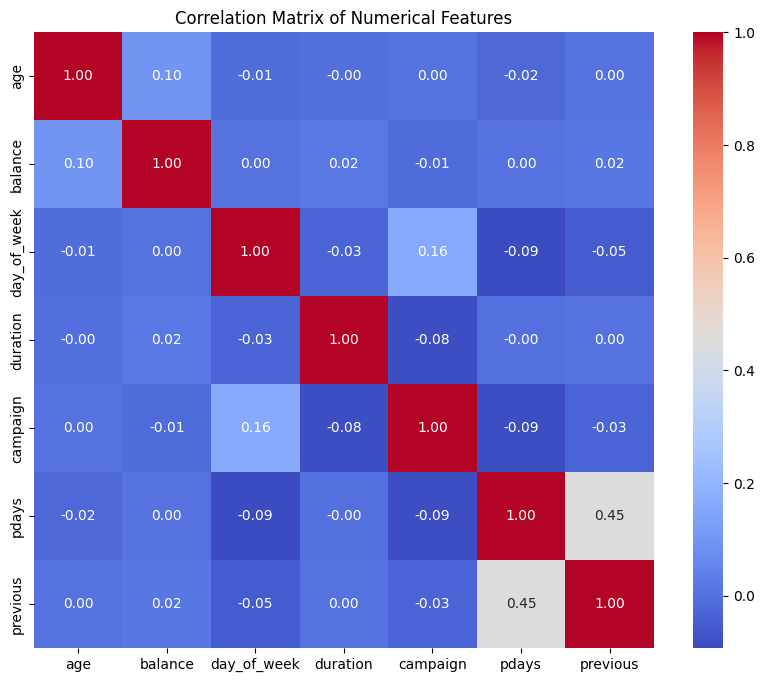

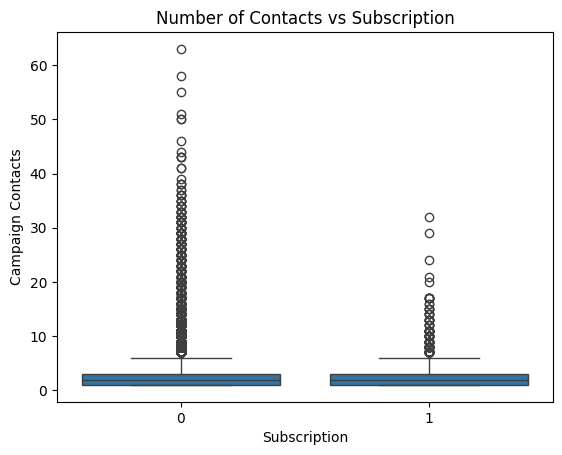

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine features and target for EDA
eda_df = X.copy()
eda_df['y'] = y['y']

# Basic dataset information
print("Dataset shape:")
print(eda_df.shape)

print("\nDataset info:")
print(eda_df.info())

print("\nStatistical summary for numerical variables:")
print(eda_df.describe())

# Target distribution
print("\nTarget variable distribution:")
print(eda_df['y'].value_counts())

plt.figure()
sns.countplot(x='y', data=eda_df)
plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

# Age distribution
plt.figure()
sns.histplot(eda_df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Balance distribution
plt.figure()
sns.histplot(eda_df['balance'], bins=30, kde=True)
plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

# Subscription by job
plt.figure(figsize=(10, 5))
sns.countplot(y='job', hue='y', data=eda_df)
plt.title("Subscription by Job Type")
plt.xlabel("Count")
plt.ylabel("Job")
plt.show()

# Subscription by education
plt.figure(figsize=(8, 5))
sns.countplot(x='education', hue='y', data=eda_df)
plt.title("Subscription by Education Level")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

# Subscription by housing loan
plt.figure()
sns.countplot(x='housing', hue='y', data=eda_df)
plt.title("Subscription by Housing Loan Status")
plt.xlabel("Housing Loan")
plt.ylabel("Count")
plt.show()

# Subscription by personal loan
plt.figure()
sns.countplot(x='loan', hue='y', data=eda_df)
plt.title("Subscription by Personal Loan Status")
plt.xlabel("Personal Loan")
plt.ylabel("Count")
plt.show()

# Contact duration vs subscription
plt.figure()
sns.boxplot(x='y', y='duration', data=eda_df)
plt.title("Call Duration vs Subscription")
plt.xlabel("Subscription")
plt.ylabel("Duration")
plt.show()

# Correlation matrix for numerical features
numerical_features = eda_df.select_dtypes(include=['int64']).drop(columns=['y'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_features.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Campaign contacts vs subscription
plt.figure()
sns.boxplot(x='y', y='campaign', data=eda_df)
plt.title("Number of Contacts vs Subscription")
plt.xlabel("Subscription")
plt.ylabel("Campaign Contacts")
plt.show()

# Machine Learning

## Logistic Regression

Evaluation Metrics
Accuracy: 0.9000
Precision: 0.62
Recall: 0.3223
F1 Score: 0.4241

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.62      0.32      0.42      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.65      0.68      9043
weighted avg       0.88      0.90      0.88      9043


Logistic Regression Confusion Matrix
[[7776  209]
 [ 717  341]]

Top 10 Most Important Features from Logistic Regression
             feature  importance
60         month_mar    1.553506
67  poutcome_success    1.346995
3           duration    1.275807
57         month_jan    1.134173
65  poutcome_failure    1.008122
61         month_may    0.865991
63         month_oct    0.808130
64         month_sep    0.799436
55         month_dec    0.783044
62         month_nov    0.734163


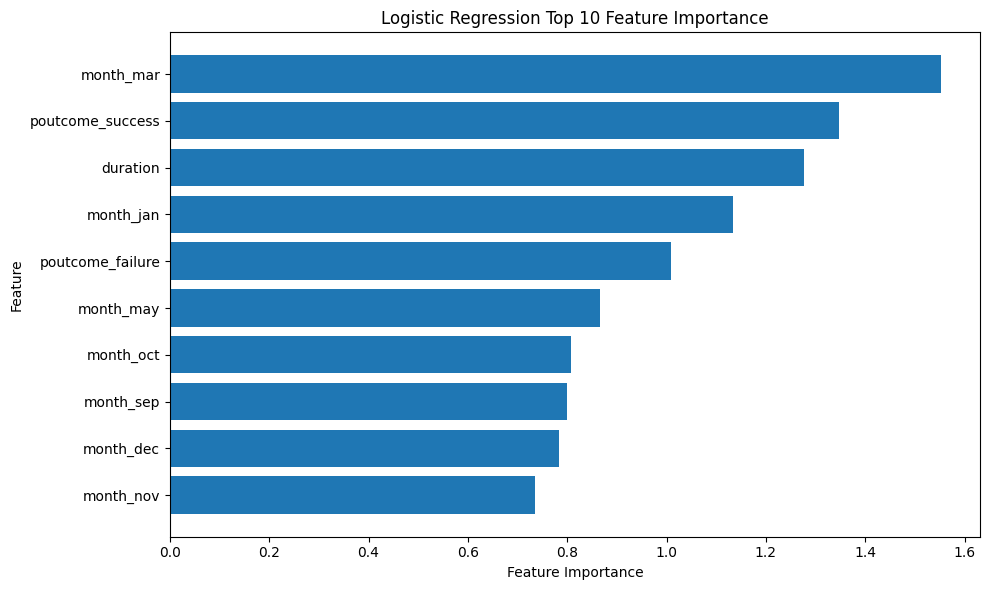

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# OPTIMIZED PREPROCESSING
numerical_transformer_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_poly, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Apply the updated preprocessing
X_train_poly = preprocessor_poly.fit_transform(X_train)
X_test_poly = preprocessor_poly.transform(X_test)

# GRID SEARCH
param_grid = {
    'C': [0.05, 0.1, 1, 5],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=3000), 
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_poly, y_train['y'])
best_lr_model = grid_lr.best_estimator_

# PREDICTION
y_pred_lr = best_lr_model.predict(X_test_poly)

# EVALUATION METRICS SECTION
print("Evaluation Metrics")
print(f"Accuracy: {round(accuracy_score(y_test['y'], y_pred_lr), 2):.4f}")
print("Precision:", round(precision_score(y_test['y'], y_pred_lr), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_lr), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_lr), 4))

print("\nLogistic Regression Classification Report")
print(classification_report(y_test['y'], y_pred_lr))

print("\nLogistic Regression Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_lr))

# FEATURE IMPORTANCE EXTRACTION
num_features_poly = (
    preprocessor_poly
    .named_transformers_['num']
    .named_steps['poly']
    .get_feature_names_out(numerical_cols)
)

cat_features_names = (
    preprocessor_poly
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
)

feature_names_final = np.concatenate([num_features_poly, cat_features_names])

# Importance Extraction
lr_coefficients = best_lr_model.coef_[0]

lr_importance_df = pd.DataFrame({
    'feature': feature_names_final,
    'importance': np.abs(lr_coefficients)
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Most Important Features from Logistic Regression")
print(lr_importance_df.head(10))

# FEATURE IMPORTANCE PLOT
top_lr_features = lr_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_lr_features['feature'], top_lr_features['importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Logistic Regression Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Residual Neural Network (ResNet)

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step
Evaluation Metrics
Accuracy: 0.9028
Precision: 0.5968
Recall: 0.5217
F1 Score: 0.5567

Residual Network Classification Report
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      7985
           1       0.60      0.52      0.56      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.74      0.75      9043
weighted avg       0.90      0.90      0.90      9043


Residual Network Confusion Matrix
[[7612  373]
 [ 506  552]]

Top 10 Most Important Features from Residual Network
             feature  importance
3           duration    0.049585
2        day_of_week    0.021387
5              pdays    0.009997
40         month_may    0.007829
37         month_jul    0.005949
6           previous    0.005817
46  poutcome_success    0.005419
35         month_feb    0.005419
41         month_nov    0.005264
33         month_aug    0.004114


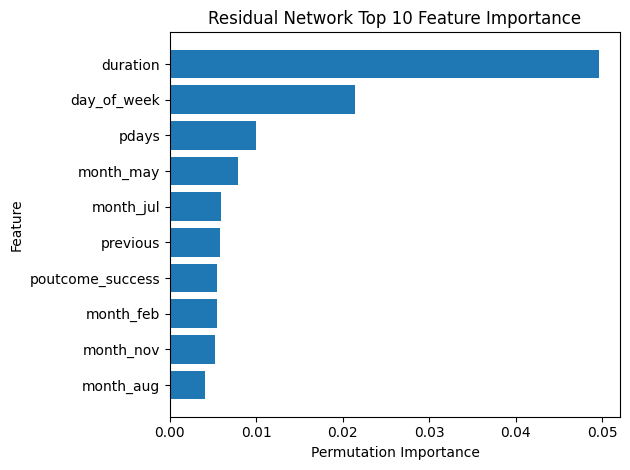

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Add, Input, Activation
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrapper class to make Keras Functional API compatible with Scikit-Learn
class KerasResNetWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
    def fit(self, X, y):
        return self
    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

# Residual Neural Network Architecture
def build_resnet(input_shape):
    inputs = Input(shape=(input_shape,))

    # Initial Dense Layer
    x = Dense(128, activation='relu')(inputs)
    x = BatchNormalization()(x)

    # First Residual Block
    shortcut = x
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = Add()([shortcut, x]) # Skip connection
    x = Activation('relu')(x)

    # Second Residual Block
    shortcut = x
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = Add()([shortcut, x]) # Skip connection
    x = Activation('relu')(x)

    # Output Layer
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model Training
resnet_model = build_resnet(X_train_processed.shape[1])
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

resnet_model.fit(
    X_train_processed, y_train['y'],
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Prediction
y_pred_probs = resnet_model.predict(X_test_processed)
y_pred_resnet = (y_pred_probs > 0.5).astype(int).flatten()

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_resnet), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_resnet), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_resnet), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_resnet), 4))

print("\nResidual Network Classification Report")
print(classification_report(y_test['y'], y_pred_resnet))

# Confusion Matrix
print("\nResidual Network Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_resnet))

# Get feature names from original preprocessing (used for ResNet)
num_features = numerical_cols

cat_features_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
)

feature_names_resnet = np.concatenate([num_features, cat_features_names])

# Feature Importance Using Permutation
wrapped_resnet = KerasResNetWrapper(resnet_model)

resnet_perm = permutation_importance(
    wrapped_resnet,
    X_test_processed,
    y_test['y'],
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

resnet_importance_df = pd.DataFrame({
    'feature': feature_names_resnet,
    'importance': resnet_perm.importances_mean
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Most Important Features from Residual Network")
print(resnet_importance_df.head(10))

# Feature Importance Plot
top_resnet_features = resnet_importance_df.head(10)

plt.figure()
plt.barh(top_resnet_features['feature'], top_resnet_features['importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Residual Network Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Multi Layer Perceptron Neural Network

Evaluation Metrics
Accuracy: 0.9034
Precision: 0.6201
Recall: 0.449
F1 Score: 0.5208

Neural Network (MLP) Classification Report
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7985
           1       0.62      0.45      0.52      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.71      0.73      9043
weighted avg       0.89      0.90      0.90      9043


Neural Network (MLP) Confusion Matrix
[[7694  291]
 [ 583  475]]

Top 10 Most Important Features from Neural Network (MLP)
             feature  importance
3           duration    0.040783
46  poutcome_success    0.005043
2        day_of_week    0.004910
5              pdays    0.004578
41         month_nov    0.002344
36         month_jan    0.002256
40         month_may    0.002145
32         month_apr    0.001990
38         month_jun    0.001946
42         month_oct    0.001814


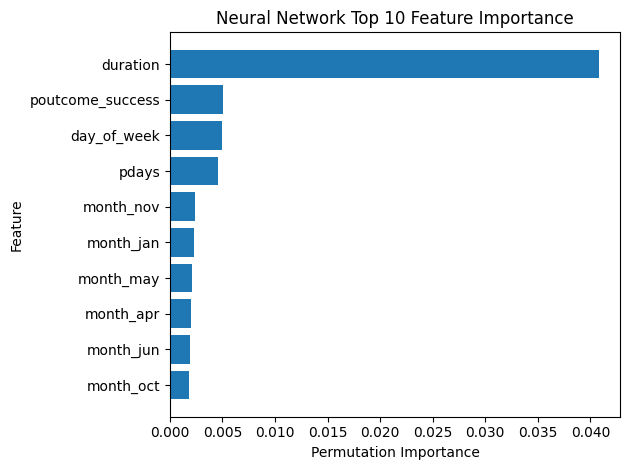

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# MLP Training
# Increased hidden layer sizes and added early stopping for better accuracy
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp_model.fit(X_train_processed, y_train['y'])

y_pred_mlp = mlp_model.predict(X_test_processed)

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_mlp), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_mlp), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_mlp), 4))

print("\nNeural Network (MLP) Classification Report")
print(classification_report(y_test['y'], y_pred_mlp))

# Confusion Matrix
print("\nNeural Network (MLP) Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_mlp))

# Get feature names from original preprocessing (used for ResNet)
num_features = numerical_cols

cat_features_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
)

feature_names_resnet = np.concatenate([num_features, cat_features_names])

# Feature Importance Using Permutation
mlp_perm = permutation_importance(
    mlp_model,
    X_test_processed,
    y_test['y'],
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

mlp_importance_df = pd.DataFrame({
    'feature': feature_names_resnet,
    'importance': mlp_perm.importances_mean
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Most Important Features from Neural Network (MLP)")
print(mlp_importance_df.head(10))

# Feature Importance Plot
top_mlp_features = mlp_importance_df.head(10)

plt.figure()
plt.barh(top_mlp_features['feature'], top_mlp_features['importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Neural Network Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Deep Artificial Neural Network (Deep ANN)

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Evaluation Metrics
Accuracy: 0.9058
Precision: 0.6098
Recall: 0.5406
F1 Score: 0.5731

Deep ANN Classification Report
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      7985
           1       0.61      0.54      0.57      1058

    accuracy                           0.91      9043
   macro avg       0.77      0.75      0.76      9043
weighted avg       0.90      0.91      0.90      9043


Deep ANN Confusion Matrix
[[7619  366]
 [ 486  572]]

Top 10 Most Important Features from Deep ANN
             feature  importance
3           duration    0.046378
2        day_of_week    0.026739
5              pdays    0.010439
32         month_apr    0.004711
46  poutcome_success    0.004512
37         month_jul    0.004268
35         month_feb    0.004246
33         month_aug    0.004025
36         month_jan    0.003649
41         month_nov    0.003251


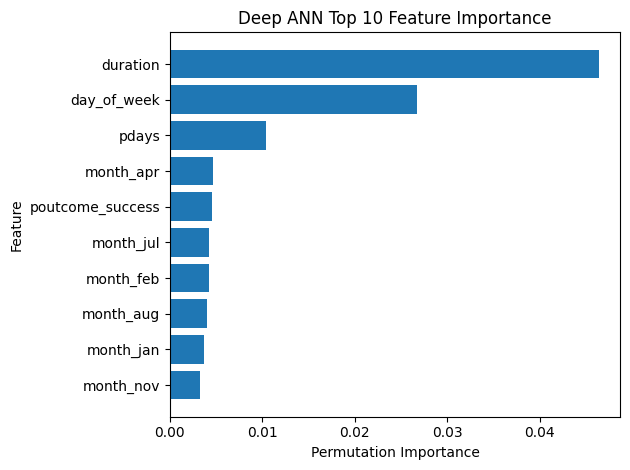

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrapper class to make Keras compatible with Scikit-Learn inspection tools
class KerasBatchClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
    def fit(self, X, y):
        return self
    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

# Deep ANN Training
keras_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

keras_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

keras_model.fit(
    X_train_processed, y_train['y'],
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Prediction
y_pred_probs = keras_model.predict(X_test_processed)
y_pred_keras = (y_pred_probs > 0.5).astype(int).flatten()

# Evaluation Metrics Section
print("Evaluation Metrics")
print("Accuracy:", round(accuracy_score(y_test['y'], y_pred_keras), 4))
print("Precision:", round(precision_score(y_test['y'], y_pred_keras), 4))
print("Recall:", round(recall_score(y_test['y'], y_pred_keras), 4))
print("F1 Score:", round(f1_score(y_test['y'], y_pred_keras), 4))

print("\nDeep ANN Classification Report")
print(classification_report(y_test['y'], y_pred_keras))

# Confusion Matrix
print("\nDeep ANN Confusion Matrix")
print(confusion_matrix(y_test['y'], y_pred_keras))

# Feature Importance Using Permutation
wrapped_model = KerasBatchClassifier(keras_model)

keras_perm = permutation_importance(
    wrapped_model,
    X_test_processed,
    y_test['y'],
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

keras_importance_df = pd.DataFrame({
    'feature': feature_names_resnet,
    'importance': keras_perm.importances_mean
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Most Important Features from Deep ANN")
print(keras_importance_df.head(10))

# Feature Importance Plot
top_keras_features = keras_importance_df.head(10)

plt.figure()
plt.barh(top_keras_features['feature'], top_keras_features['importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Deep ANN Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Model Comparison

Model Performance Comparison Table
                  Model  Accuracy  Precision  Recall  F1 Score
0   Logistic Regression    0.9000     0.6200  0.3223    0.4241
1      Residual Network    0.9028     0.5968  0.5217    0.5567
2  Neural Network (MLP)    0.9034     0.6201  0.4490    0.5208
3              Deep ANN    0.9058     0.6098  0.5406    0.5731


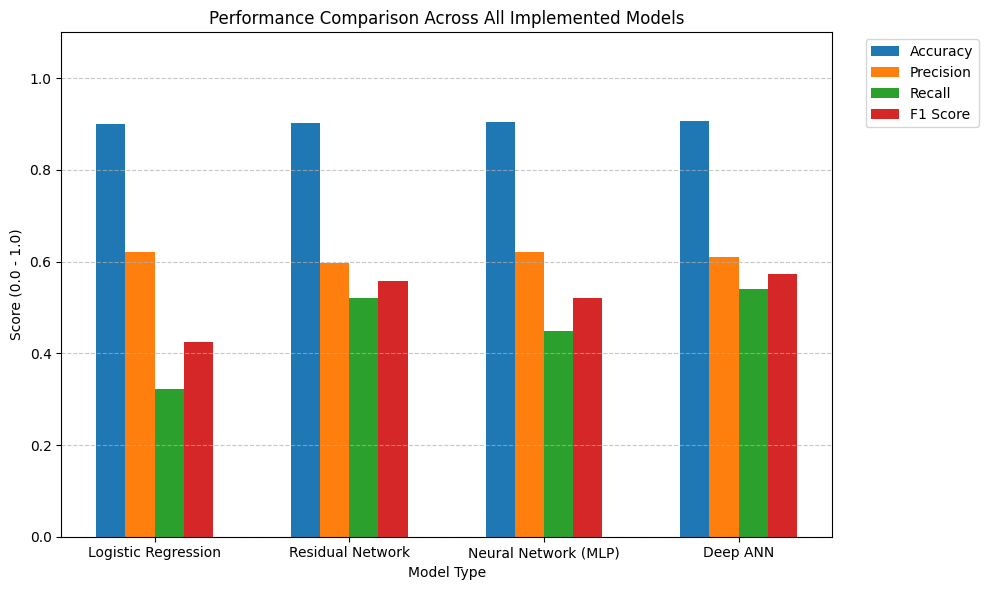

In [24]:
# Create metrics comparison table for the 4 models implemented
metrics_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Residual Network',
        'Neural Network (MLP)',
        'Deep ANN'
    ],
    'Accuracy': [
        round(accuracy_score(y_test['y'], y_pred_lr), 2),
        accuracy_score(y_test['y'], y_pred_resnet),
        accuracy_score(y_test['y'], y_pred_mlp),
        accuracy_score(y_test['y'], y_pred_keras)
    ],
    'Precision': [
        precision_score(y_test['y'], y_pred_lr),
        precision_score(y_test['y'], y_pred_resnet),
        precision_score(y_test['y'], y_pred_mlp),
        precision_score(y_test['y'], y_pred_keras)
    ],
    'Recall': [
        recall_score(y_test['y'], y_pred_lr),
        recall_score(y_test['y'], y_pred_resnet),
        recall_score(y_test['y'], y_pred_mlp),
        recall_score(y_test['y'], y_pred_keras)
    ],
    'F1 Score': [
        f1_score(y_test['y'], y_pred_lr),
        f1_score(y_test['y'], y_pred_resnet),
        f1_score(y_test['y'], y_pred_mlp),
        f1_score(y_test['y'], y_pred_keras)
    ]
})

# Round values for presentation
metrics_df.iloc[:, 1:] = metrics_df.iloc[:, 1:].round(4)

print("Model Performance Comparison Table")
print(metrics_df)

# Set up the visualization
models = metrics_df['Model']
x = np.arange(len(models))
width = 0.15 # Adjusted width for 4 metrics

plt.figure(figsize=(10, 6))

# Plotting each metric
plt.bar(x - 1.5*width, metrics_df['Accuracy'], width, label='Accuracy', color='#1f77b4')
plt.bar(x - 0.5*width, metrics_df['Precision'], width, label='Precision', color='#ff7f0e')
plt.bar(x + 0.5*width, metrics_df['Recall'], width, label='Recall', color='#2ca02c')
plt.bar(x + 1.5*width, metrics_df['F1 Score'], width, label='F1 Score', color='#d62728')

plt.xlabel("Model Type")
plt.ylabel("Score (0.0 - 1.0)")
plt.title("Performance Comparison Across All Implemented Models")
plt.xticks(x, models)
plt.ylim(0, 1.1) # Added some space at the top for the legend
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()